# Lesson 1 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/1/1-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives you a function signature and a docstring stating exactly
what the function must return. Replace the `raise NotImplementedError` with
your implementation. The cell immediately after each task contains
`assert` statements that check your work.

**A failing assert is information, not a grade.** It tells you that the
behaviour does not yet match the contract. Read the assertion message, fix
the function, re-run the cell. There is no penalty for running a cell
twenty times.

The written questions are marked. They are the part of this homework that
carries the learning objective: each one asks you to *run something both
ways and explain the difference*, not to recall a fact. Answers of one
sentence will not be enough; answers of one paragraph, referring to numbers
you actually produced, will.

Every function you need has been demonstrated in `1-practice.ipynb`. Each
task names the section — `see Practice 1 §3.6` — where the relevant material
is. You should not need any other documentation, and you should not need to
search the internet. If you find yourself wanting to, the reference is
probably in the practice notebook and worth finding.

## Before you submit

**Runtime → Restart and run all must complete without error**, with every
assert passing. A notebook that only works because you ran the cells in an
unusual order is not reproducible, and reproducibility is the subject of
§4.1 of the practice notebook.

Then **File → Download → Download .ipynb**, rename the file to
`1-homework-results.ipynb`, and commit it to your fork under
`practice/1/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

Run this first. It is the same configuration cell as the practice notebook.

In [ ]:
import sys

import numpy as np
import matplotlib.pyplot as plt

SEED = 20250919
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["lines.linewidth"] = 2.0

print("python", sys.version.split()[0], "| numpy", np.__version__)

python 3.13.15 | numpy 2.1.3


## 2. Task 1 — Describe an array

Mechanical. Return the five attributes that describe an array's layout.

*see Practice 1 §3.2*

In [ ]:
def describe_array(arr):
    """Return a dict describing the memory layout of `arr`.

    Keys, exactly these five:
        'dtype'    the element type, as a string (use str(...) on the dtype)
        'shape'    the shape, as a tuple
        'ndim'     the number of dimensions, as an int
        'size'     the total number of elements, as an int
        'nbytes'   the total number of bytes occupied by the data, as an int

    No allocation and no copying: read the attributes off `arr`.
    """
    return {
    "dtype": str(arr.dtype),
    "shape": arr.shape,
    "ndim": arr.ndim,
    "size": arr.size,
    "nbytes": arr.nbytes
}


In [ ]:
_result = describe_array(np.zeros((3, 4), dtype=np.float64))
assert set(_result) == {"dtype", "shape", "ndim", "size", "nbytes"}, \
    f"expected exactly those five keys, got {sorted(_result)}"
assert _result["shape"] == (3, 4), f"shape wrong: {_result['shape']}"
assert _result["ndim"] == 2, f"ndim wrong: {_result['ndim']}"
assert _result["size"] == 12, f"size wrong: {_result['size']}"
assert _result["nbytes"] == 96, f"nbytes wrong: {_result['nbytes']} (12 elements x 8 bytes)"
assert "float64" in _result["dtype"], f"dtype wrong: {_result['dtype']}"

_int_result = describe_array(np.arange(10, dtype=np.int32))
assert _int_result["nbytes"] == 40, "an int32 array of 10 elements occupies 40 bytes"
assert _int_result["ndim"] == 1

print("Task 1 passed.")

Task 1 passed.


## 3. Task 2 — A view bug, and the fix

The function below is supposed to return a copy of the middle of an array
with its values clipped to zero, leaving the caller's array untouched. It
does not. Find the defect and repair it.

Do not change the signature and do not change what the function returns —
only make it stop modifying its argument.

*see Practice 1 §3.6*

In [ ]:
def zero_the_middle(arr, start, stop):
    """Return a NEW array holding arr[start:stop] with every value set to 0.

    `arr` must not be modified. The returned array must have length
    stop - start and must not share memory with `arr`.

    The body below is the broken version. Fix it.
    """
    middle = arr[start:stop].copy()
    middle[:] = 0
    return middle

In [ ]:
_original = np.arange(10)
_untouched = np.arange(10)
_returned = zero_the_middle(_original, 3, 6)

assert np.array_equal(_original, _untouched), \
    f"the argument was modified: {_original} should still be {_untouched}"
assert _returned.shape == (3,), f"wrong length: {_returned.shape}"
assert np.all(_returned == 0), f"values not zeroed: {_returned}"
assert not np.shares_memory(_returned, _original), \
    "the result still shares memory with the argument"

print("Task 2 passed.")

Task 2 passed.


## 4. Task 3 — Standardise the columns of a matrix

Applied. Subtract each column's mean and divide by each column's standard
deviation, using broadcasting rather than a loop over columns.

This is what `StandardScaler` does, and Practice 2 §9 will use the
scikit-learn object. Writing it once by hand is the point.

*see Practice 1 §3.7 and §3.8*

In [ ]:
def standardise_columns(matrix):
    """Return `matrix` with every column centred and scaled to unit variance.

    For each column j:  out[:, j] = (matrix[:, j] - mean_j) / sd_j

    Use the population standard deviation (NumPy's default, ddof=0).
    The result has the same shape as `matrix`. Do not modify `matrix`.
    Use broadcasting; do not write a `for` loop over the columns.
    """
    mean = np.mean(matrix, axis=0)
    std = np.std(matrix, axis=0)
    return (matrix - mean) / std

In [ ]:
_data = np.array([[1.0, 100.0],
                  [2.0, 200.0],
                  [3.0, 300.0],
                  [4.0, 400.0]])
_before = _data.copy()
_scaled = standardise_columns(_data)

assert _scaled.shape == _data.shape, f"shape changed: {_scaled.shape}"
assert np.array_equal(_data, _before), "the input matrix was modified"
assert np.allclose(_scaled.mean(axis=0), 0.0), \
    f"columns not centred, means are {_scaled.mean(axis=0)}"
assert np.allclose(_scaled.std(axis=0), 1.0), \
    f"columns not unit variance, sds are {_scaled.std(axis=0)}"
# The two columns are the same numbers on different scales, so after
# standardising they must be identical.
assert np.allclose(_scaled[:, 0], _scaled[:, 1]), \
    "a linear rescaling of a column should standardise to the same values"

_wide = rng.normal(5.0, 3.0, size=(200, 7))
assert np.allclose(standardise_columns(_wide).mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(standardise_columns(_wide).std(axis=0), 1.0)

print("Task 3 passed.")

Task 3 passed.


## 5. Task 4 — Reductions along an axis

Mechanical, but the axis argument is the thing being tested. Read the
docstring carefully: two of these collapse rows and two collapse columns.

*see Practice 1 §3.8*

In [ ]:
def axis_summary(matrix):
    """Return a dict of four reductions of a 2-D array.

    Keys and contents:
        'per_column_mean'  one value per COLUMN, shape (n_columns,)
        'per_row_sum'      one value per ROW,    shape (n_rows,)
        'per_row_max'      one value per ROW,    shape (n_rows,)
        'grand_total'      the sum of every element, a scalar float

    Return NumPy arrays for the first three and a Python/NumPy float for
    the last.
    """
    return {
        "per_column_mean": np.mean(matrix, axis=0),
        "per_row_sum": np.sum(matrix, axis=1),
        "per_row_max": np.max(matrix, axis=1),
        "grand_total": float(np.sum(matrix))
}

In [ ]:
_grid = np.array([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
_summary = axis_summary(_grid)

assert _summary["per_column_mean"].shape == (3,), \
    f"per_column_mean should have one value per column: {_summary['per_column_mean'].shape}"
assert np.allclose(_summary["per_column_mean"], [2.5, 3.5, 4.5])
assert _summary["per_row_sum"].shape == (2,), \
    f"per_row_sum should have one value per row: {_summary['per_row_sum'].shape}"
assert np.allclose(_summary["per_row_sum"], [6.0, 15.0])
assert np.allclose(_summary["per_row_max"], [3.0, 6.0])
assert np.isclose(_summary["grand_total"], 21.0)

# A non-square array catches an axis swapped by accident.
_tall = rng.normal(size=(50, 4))
_tall_summary = axis_summary(_tall)
assert _tall_summary["per_column_mean"].shape == (4,)
assert _tall_summary["per_row_sum"].shape == (50,)

print("Task 4 passed.")

Task 4 passed.


### Question 1 — the axis argument

Take the `(50, 4)` array `_tall` from the cell above. Compute `_tall.sum()`,
`_tall.sum(axis=0)` and `_tall.sum(axis=1)`, and print the shape of each.

Explain, in your own words, **why `axis=0` produces four numbers and not
fifty**, given that the array has fifty rows. Then state which of the three
you would use to answer the question "what is the average value of each
feature across all samples", and why.

In [ ]:
print("_tall.sum():", _tall.sum())
print("shape:", np.shape(_tall.sum()))

print("_tall.sum(axis=0):", _tall.sum(axis=0))
print("shape:", _tall.sum(axis=0).shape)

print("_tall.sum(axis=1):", _tall.sum(axis=1))
print("shape:", _tall.sum(axis=1).shape)

_tall.sum(): -9.792221026356906
shape: ()
_tall.sum(axis=0): [-8.02177989 -0.81004707  8.21145867 -9.17185273]
shape: (4,)
_tall.sum(axis=1): [-0.50510624 -2.09015697  0.15802573  0.22961949 -0.40134908  1.10646439
  2.90490295  1.01447592  1.11822027 -3.48374535  0.81667958  3.52514633
 -1.80920476  1.83156271 -4.02562997 -2.42957279  1.44618058  1.13199867
 -0.61684538  1.78645098  0.75503361  0.57046469 -3.48153912 -0.45100874
 -4.25064576 -0.40944265  2.64439616 -2.02693328 -0.08706021  1.12517462
 -1.78183882  0.36524314  1.32938319 -0.63146496 -5.28006837 -0.28121492
 -1.12785243 -4.68714087  4.05556111  2.49521876  1.05249556  2.00795355
 -1.0681827  -0.16955788  1.22803338 -1.6438678   1.56742297 -0.69945049
 -1.54850182 -1.07094802]
shape: (50,)


**Your answer:**

_tall.sum() sums all elements of the array and returns a single scalar value, so its shape is (). In my result, the total sum was approximately -9.7922. _tall.sum(axis=0) collapses the rows and calculates one sum for each column. Since the array has 4 columns, the result contains four values and has shape (4,), even though the array has 50 rows. _tall.sum(axis=1) instead collapses the columns and calculates one sum for each row, so it produces 50 values with shape (50,). To find the average value of each feature across all samples, I would use _tall.mean(axis=0), because the rows represent samples and the columns represent features. This produces one mean value for each of the four features.

## 6. Task 5 — Outliers by the k-sigma rule

Applied. Generalise the practice notebook's 3σ filter to an arbitrary threshold.

*see Practice 1 §3.9 and §4.7*

In [ ]:
def sigma_outliers(sample, k=3.0):
    """Flag the values of `sample` that lie more than k standard deviations
    from the sample mean.

    Use the mean and standard deviation OF THE SAMPLE itself, not assumed
    values, and NumPy's default ddof=0 for the standard deviation.

    Return a tuple (mask, values):
        mask    a boolean array, the same shape as `sample`, True where the
                value is an outlier
        values  the outlying values themselves, in their original order

    Build the mask with a vectorised comparison; do not loop.
    """
    mean = np.mean(sample)
    std = np.std(sample)

    mask = np.abs(sample - mean) > k * std
    values = sample[mask]

    return mask, values

In [ ]:
_plain = np.array([1.0, 2.0, 3.0, 2.0, 1.0, 50.0])
_mask, _values = sigma_outliers(_plain, k=2.0)

assert _mask.dtype == bool, f"mask must be boolean, got {_mask.dtype}"
assert _mask.shape == _plain.shape, f"mask shape {_mask.shape} != sample shape {_plain.shape}"
assert _mask.sum() == 1, f"expected exactly one outlier at k=2, found {_mask.sum()}"
assert np.allclose(_values, [50.0]), f"wrong value flagged: {_values}"

# On a clean normal sample the 3-sigma rule should flag very few points.
_normal = rng.normal(0.0, 1.0, 10_000)
_normal_mask, _ = sigma_outliers(_normal, k=3.0)
_rate = _normal_mask.mean()
assert 0.0 < _rate < 0.01, \
    f"flag rate {_rate:.4f} is implausible for 3 sigma on normal data (expect ~0.0027)"

# A larger threshold can never flag more points than a smaller one.
assert sigma_outliers(_normal, k=4.0)[0].sum() <= _normal_mask.sum()

print(f"Task 5 passed. 3-sigma flag rate on 10,000 normal draws: {_rate:.4%}")

Task 5 passed. 3-sigma flag rate on 10,000 normal draws: 0.3100%


### Question 2 — the threshold is a choice

Using the 10 000-point normal sample `_normal`, run `sigma_outliers` at
`k = 1, 2, 3, 4, 5` and print the number of points flagged at each.

Then answer: the theoretical fractions outside k standard deviations of a
normal distribution are about 32 %, 4.6 %, 0.27 %, 0.0063 % and 0.000057 %.
Compare your counts with those. **At which k does the sample stop having
enough data to estimate the rate at all**, and what does that imply about
using a very large k to define an outlier?

Finally: none of the points in `_normal` is an error — they all came from
the same generator. Describe one concrete situation in which you *would* be
justified in deleting a flagged point, and say what evidence would justify
it.

In [ ]:
for k in [1, 2, 3, 4, 5]:
    mask, values = sigma_outliers(_normal, k=k)
    print(f"k={k}: {mask.sum()} points flagged")

k=1: 3163 points flagged
k=2: 454 points flagged
k=3: 31 points flagged
k=4: 2 points flagged
k=5: 0 points flagged


**Your answer:**
For my 10,000-point sample, I found 3163 points outside 1 standard deviation, 454 outside 2, 31 outside 3, 2 outside 4, and 0 outside 5. The first three results are reasonably close to the theoretical rates of about 32%, 4.6%, and 0.27%, which would correspond to approximately 3200, 460, and 27 points. At k=4 the theoretical rate predicts less than one point on average in a sample of this size, so observing 2 points is strongly affected by random sampling variation. At k=5 the expected number is much smaller than one and my sample contains no such points. Therefore, around k=4–5 this 10,000-point sample no longer contains enough observations to estimate the tail rate reliably. This also shows that choosing a very large k as an outlier threshold can make the rule too insensitive and may fail to identify unusual observations in realistically sized datasets.

I would delete a flagged observation only if there were independent evidence that it was an error rather than simply an extreme but valid value. For example, if a temperature sensor normally records plausible measurements but one flagged value was produced at the exact time the sensor diagnostic log reported a hardware malfunction, I would have evidence that the measurement was corrupted and could justify removing it. A large deviation from the mean by itself would not be sufficient evidence for deletion.

## 7. Task 6 — A NaN-aware mean, written by hand

Mechanical. Do not call `np.nanmean`; the point is to build it from the
masking tools.

*see Practice 1 §3.9 and §3.10*

In [ ]:
def mean_ignoring_nan(sample):
    """Return the mean of the non-missing values of `sample`.

    Equivalent to np.nanmean, but you must implement it with np.isnan and
    boolean masking rather than calling any nan-aware NumPy reduction.

    If every value is missing, return np.nan.
    """
    mask = ~np.isnan(sample)
    valid_values = sample[mask]

    if valid_values.size == 0:
        return np.nan

    return valid_values.mean()

In [ ]:
assert np.isclose(mean_ignoring_nan(np.array([1.0, 2.0, np.nan, 4.0])), 7.0 / 3.0)
assert np.isclose(mean_ignoring_nan(np.array([5.0, 5.0, 5.0])), 5.0)
assert np.isnan(mean_ignoring_nan(np.array([np.nan, np.nan]))), \
    "an all-missing sample has no mean; return np.nan"

_with_gaps = rng.normal(0.0, 1.0, 1000)
_with_gaps[rng.choice(1000, size=100, replace=False)] = np.nan
assert np.isclose(mean_ignoring_nan(_with_gaps), np.nanmean(_with_gaps)), \
    "your result should agree with np.nanmean"
assert np.isnan(_with_gaps.mean()), \
    "sanity check: the plain mean of an array containing NaN is NaN"

print("Task 6 passed.")

Task 6 passed.


## 8. Task 7 — How well does a sample know its own distribution

Applied. Draw samples of increasing size from a known normal distribution
and measure how far the estimated parameters fall from the true ones.

*see Practice 1 §4.1 and §4.6*

In [ ]:
def recover_parameters(true_mu, true_sigma, sizes, generator):
    """Estimate mu and sigma from samples of several sizes.

    For each n in `sizes`, draw n values from normal(true_mu, true_sigma)
    using `generator`, and record the sample mean and the UNBIASED sample
    standard deviation (ddof=1).

    Draw the samples in the order the sizes are given, taking every sample
    from the same `generator` object, so that the result is reproducible
    for a given seed.

    Return a dict with three keys, each a NumPy array of len(sizes):
        'n'          the sample sizes, as given
        'mu_hat'     the estimated means
        'sigma_hat'  the estimated standard deviations
    """
    mu_hat = []
    sigma_hat = []

    for n in sizes:
        sample = generator.normal(true_mu, true_sigma, size=n)
        mu_hat.append(np.mean(sample))
        sigma_hat.append(np.std(sample, ddof=1))

    return {
        "n": np.array(sizes),
        "mu_hat": np.array(mu_hat),
        "sigma_hat": np.array(sigma_hat)
}

In [ ]:
_sizes = [10, 100, 1_000, 10_000, 100_000]
_recovered = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))

assert set(_recovered) == {"n", "mu_hat", "sigma_hat"}
assert len(_recovered["mu_hat"]) == len(_sizes)
assert np.array_equal(_recovered["n"], np.array(_sizes))

# Reproducible: the same seed must give the same estimates.
_again = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))
assert np.allclose(_recovered["mu_hat"], _again["mu_hat"]), \
    "same seed gave different answers; are you drawing from the generator you were passed?"

# The largest sample must land close to the truth.
assert abs(_recovered["mu_hat"][-1] - 2.0) < 0.1, \
    f"mu estimate from 100,000 draws is {_recovered['mu_hat'][-1]:.4f}, expected near 2.0"
assert abs(_recovered["sigma_hat"][-1] - 5.0) < 0.1, \
    f"sigma estimate from 100,000 draws is {_recovered['sigma_hat'][-1]:.4f}, expected near 5.0"

# and the error should shrink as n grows
_err_small = abs(_recovered["mu_hat"][0] - 2.0)
_err_large = abs(_recovered["mu_hat"][-1] - 2.0)
assert _err_large < _err_small, "the estimate should improve with more data"

for n, mu, sd in zip(_recovered["n"], _recovered["mu_hat"], _recovered["sigma_hat"]):
    print(f"n = {n:7,}   mu_hat = {mu:8.4f}   sigma_hat = {sd:8.4f}")
print("\nTask 7 passed.")

n =      10   mu_hat =   2.4234   sigma_hat =   3.9067
n =     100   mu_hat =   2.2577   sigma_hat =   4.9827
n =   1,000   mu_hat =   1.7686   sigma_hat =   4.9318
n =  10,000   mu_hat =   2.0434   sigma_hat =   5.0002
n = 100,000   mu_hat =   1.9896   sigma_hat =   5.0035

Task 7 passed.


### Question 3 — the seed and the sample size

Two experiments.

**(a)** Call `recover_parameters(2.0, 5.0, [100], ...)` with five *different*
seeds. Record the five estimates of mu. How much do they vary?

**(b)** Call it with a single fixed seed but sizes `[100, 10_000]`. How far
is each estimate from 2.0?

Now explain the distinction these two experiments draw out. **The seed
controls one thing and the sample size controls a different thing — name
both.** In particular: does a larger seed give a better answer? Does
re-running with a new seed tell you anything you did not know? And if your
estimate at n = 100 is off by 0.4, is that a bug?

Use the error at n = 100 and at n = 10 000 to estimate how the error scales
with n, and compare it with the square-root rule from Practice 1 §4.6.

In [ ]:
# (a) n = 100, five different seeds
print("(a) Five different seeds, n=100:")

mu_estimates = []

for seed in [0, 1, 2, 3, 4]:
    result = recover_parameters(
        2.0, 5.0, [100], np.random.default_rng(seed)
    )
    mu = result["mu_hat"][0]
    mu_estimates.append(mu)
    print(f"seed={seed}: mu_hat={mu:.4f}")

print(f"range = {max(mu_estimates) - min(mu_estimates):.4f}")

# (b) Same seed, different sample sizes
print("\n(b) Fixed seed, n=100 and n=10,000:")

result = recover_parameters(
    2.0, 5.0, [100, 10_000], np.random.default_rng(0)
)

for n, mu in zip(result["n"], result["mu_hat"]):
    error = abs(mu - 2.0)
    print(f"n={n:6d}: mu_hat={mu:.4f}, error={error:.4f}")

error_100 = abs(result["mu_hat"][0] - 2.0)
error_10000 = abs(result["mu_hat"][1] - 2.0)

print(f"\nerror ratio (n=100 / n=10,000) = {error_100 / error_10000:.2f}")
print("square-root rule prediction = 10.00")

(a) Five different seeds, n=100:
seed=0: mu_hat=2.4055
seed=1: mu_hat=1.6319
seed=2: mu_hat=1.9579
seed=3: mu_hat=1.6911
seed=4: mu_hat=1.6835
range = 0.7735

(b) Fixed seed, n=100 and n=10,000:
n=   100: mu_hat=2.4055, error=0.4055
n= 10000: mu_hat=2.0219, error=0.0219

error ratio (n=100 / n=10,000) = 18.55
square-root rule prediction = 10.00


**Your answer:**

With n=100, the five different seeds produced mu estimates of 2.4055, 1.6319, 1.9579, 1.6911, and 1.6835, giving a range of about 0.7735. This shows that the seed controls the particular random sample that is generated, so changing the seed changes the estimate because of sampling variability. A larger seed does not give a better estimate; it only selects a different reproducible sequence of random numbers. Re-running the experiment with another seed demonstrates the variability that is already expected from random sampling.

With a fixed seed, the estimate for n=100 was 2.4055, with an absolute error of 0.4055 from the true mean of 2.0. For n=10,000, the estimate was 2.0219, with an error of only 0.0219. Therefore, an estimate at n=100 being off by about 0.4 is not necessarily a bug; it can be ordinary sampling variation. Sample size controls the precision of the estimate: larger samples generally produce more precise estimates.

Increasing the sample size from 100 to 10,000 is a factor of 100, so the square-root rule predicts that the typical error should decrease by about sqrt(100) = 10 times. In this particular experiment, the error decreased by about 18.55 times (0.4055 / 0.0219). This is not exactly 10 because the square-root rule describes the typical scale of sampling error rather than requiring every individual random sample to have exactly that error ratio.

## 9. Task 8 — Build a correlated cloud

Applied. Construct a 2-D Gaussian sample with a specified correlation, and
confirm you got what you asked for.

*see Practice 1 §4.9*

In [ ]:
def correlated_cloud(sd_x, sd_y, correlation, n, generator):
    """Draw `n` points from a 2-D normal centred at the origin with the given
    marginal standard deviations and correlation.

    Build the covariance matrix yourself from the three parameters:

        [[ sd_x**2,                      correlation*sd_x*sd_y ],
         [ correlation*sd_x*sd_y,        sd_y**2               ]]

    Draw from it with generator.multivariate_normal.

    Return a tuple (points, covariance):
        points      shape (n, 2)
        covariance  the 2x2 matrix you built, shape (2, 2)
    """
    covariance = np.array([
        [sd_x**2, correlation * sd_x * sd_y],
        [correlation * sd_x * sd_y, sd_y**2]
    ])

    points = generator.multivariate_normal(
        mean=[0.0, 0.0],
        cov=covariance,
        size=n
    )

    return points, covariance

In [ ]:
_points, _cov = correlated_cloud(3.0, 3.0, 0.8, 20_000, np.random.default_rng(1))

assert _points.shape == (20_000, 2), f"wrong shape: {_points.shape}"
assert _cov.shape == (2, 2)
assert np.isclose(_cov[0, 0], 9.0), f"variance of x should be sd_x**2 = 9, got {_cov[0, 0]}"
assert np.isclose(_cov[0, 1], _cov[1, 0]), "a covariance matrix is symmetric"
assert np.isclose(_cov[0, 1], 7.2), f"off-diagonal should be 0.8*3*3 = 7.2, got {_cov[0, 1]}"

_measured = np.corrcoef(_points.T)[0, 1]
assert abs(_measured - 0.8) < 0.02, \
    f"the sample correlation is {_measured:.4f}, expected close to 0.8"

# a zero correlation must give an axis-aligned cloud
_indep, _ = correlated_cloud(2.0, 5.0, 0.0, 20_000, np.random.default_rng(2))
assert abs(np.corrcoef(_indep.T)[0, 1]) < 0.03

print(f"Task 8 passed. Measured correlation {_measured:.4f} against a requested 0.8.")

Task 8 passed. Measured correlation 0.7963 against a requested 0.8.


## 10. Task 9 — A figure that can be read without its caption

Applied. Draw the two clouds side by side, correctly labelled.

Requirements, all of which the assert checks:

- one `Figure` with two `Axes`, side by side
- left panel: correlation 0.0; right panel: correlation 0.9
- both panels: an x label, a y label, a title, and equal aspect
- a title on the figure as a whole

*see Practice 1 §4.9 and §5*

In [ ]:
def compare_correlations(generator):
    """Draw two 2-D clouds side by side and return (fig, axes).

    Both clouds: sd_x = sd_y = 2.0, n = 2000, drawn with `generator`
    via correlated_cloud from Task 8.
    Left panel  correlation 0.0.
    Right panel correlation 0.9.

    Each Axes must have set_xlabel, set_ylabel, set_title and an equal
    aspect ratio. The Figure must have a suptitle.

    Return the Figure and the array of two Axes.
    """
    left_points, _ = correlated_cloud(
        2.0, 2.0, 0.0, 2000, generator
    )

    right_points, _ = correlated_cloud(
       2.0, 2.0, 0.9, 2000, generator
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(left_points[:, 0], left_points[:, 1], s=10)
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")
    axes[0].set_title("Correlation = 0.0")
    axes[0].set_aspect("equal")

    axes[1].scatter(right_points[:, 0], right_points[:, 1], s=10)
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")
    axes[1].set_title("Correlation = 0.9")
    axes[1].set_aspect("equal")

    fig.suptitle("Comparison of Correlations")

    return fig, axes

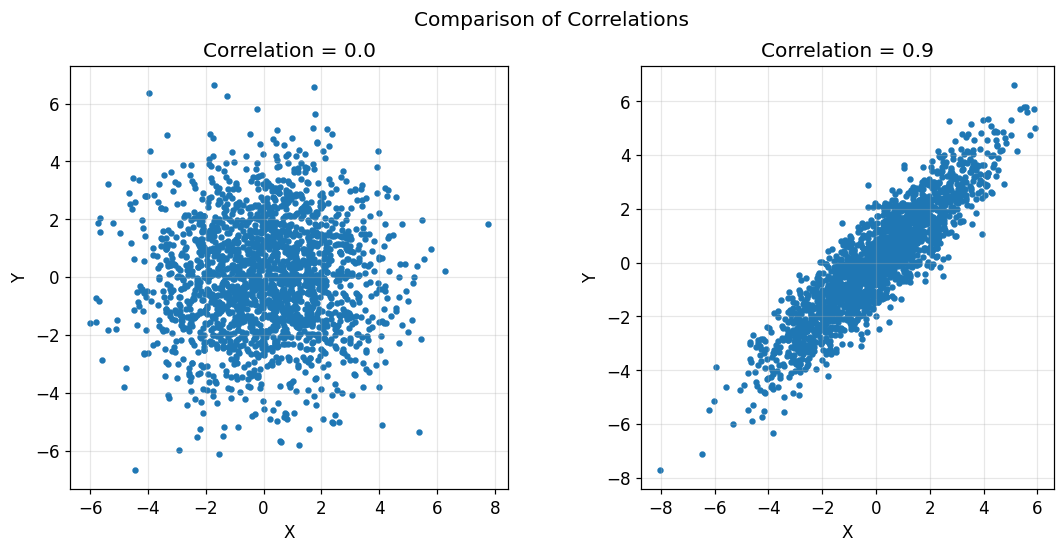

Task 9 passed.


In [ ]:
_fig, _axes = compare_correlations(np.random.default_rng(3))

assert len(_axes) == 2, f"expected two Axes, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_aspect() == 1.0, f"panel {_i} does not have equal aspect"
    assert len(_ax.collections) > 0, f"panel {_i} has nothing plotted on it"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), \
    "the figure has no suptitle"

plt.show()
print("Task 9 passed.")

### Question 4 — the off-diagonal entry

Re-run `compare_correlations` mentally, or actually, with the right-hand
correlation set to **-0.9** instead of `0.9`.

Describe what changes in the picture and what does **not**. Specifically:
does the spread of `x` alone change? Does the spread of `y` alone change?
What would you see if you plotted a histogram of just the `x` coordinate
for correlation `0.0`, `0.9` and `-0.9` — could you tell the three cases
apart from that histogram?

Then state the consequence in one sentence: what does this say about
inspecting variables one at a time?

In [ ]:
# Generate three clouds with different correlations
p0, _ = correlated_cloud(2.0, 2.0, 0.0, 2000, np.random.default_rng(3))
p_pos, _ = correlated_cloud(2.0, 2.0, 0.9, 2000, np.random.default_rng(3))
p_neg, _ = correlated_cloud(2.0, 2.0, -0.9, 2000, np.random.default_rng(3))

print("Correlation 0.0:")
print("std(x) =", p0[:, 0].std())
print("std(y) =", p0[:, 1].std())

print("\nCorrelation 0.9:")
print("std(x) =", p_pos[:, 0].std())
print("std(y) =", p_pos[:, 1].std())

print("\nCorrelation -0.9:")
print("std(x) =", p_neg[:, 0].std())
print("std(y) =", p_neg[:, 1].std())

Correlation 0.0:
std(x) = 2.01392691220897
std(y) = 1.9911939535271448

Correlation 0.9:
std(x) = 2.0186152670231956
std(y) = 2.0069605861761057

Correlation -0.9:
std(x) = 2.0069605861761066
std(y) = 2.0186152670231947


**Your answer:**

Changing the correlation from 0.9 to -0.9 changes the direction of the relationship between x and y. With correlation 0.9, the cloud slopes upward: large x values tend to occur with large y values. With correlation -0.9, the cloud slopes downward: large x values tend to occur with small y values. However, the marginal spread of x does not change, and the marginal spread of y does not change; both still have a standard deviation of approximately 2.

If I plotted a histogram of only the x coordinate for correlations 0.0, 0.9, and -0.9, the three histograms would look approximately the same. From the x histogram alone, I could not reliably determine which correlation generated the data. The correlation changes the joint relationship between x and y, not the marginal distribution of x or y individually.

Therefore, inspecting variables one at a time can hide important relationships between variables, so joint or multivariate analysis is necessary to detect dependence such as correlation.

## 11. Task 10 — Histograms and the bin count

Applied. Draw one sample three ways and decide which picture to trust.

*see Practice 1 §4.5*

In [ ]:
def histogram_grid(sample, bin_counts, density):
    """Plot `sample` as a histogram once per entry in `bin_counts`.

    One Figure, len(bin_counts) Axes in a single row. Panel i uses
    bins=bin_counts[i] and the given `density` flag for every panel.

    Each Axes needs an x label, a y label, and a title naming its bin count.
    The y label must say 'density' when density is True and 'count' when it
    is False, because those are different quantities.

    Return (fig, axes).
    """
    fig, axes = plt.subplots(
        1, len(bin_counts),
        figsize=(5 * len(bin_counts), 4)
    )

    axes = np.atleast_1d(axes)

    for ax, bins in zip(axes, bin_counts):
        ax.hist(sample, bins=bins, density=density)
        ax.set_xlabel("Value")
        ax.set_ylabel("density" if density else "count")
        ax.set_title(f"{bins} bins")

    return fig, axes

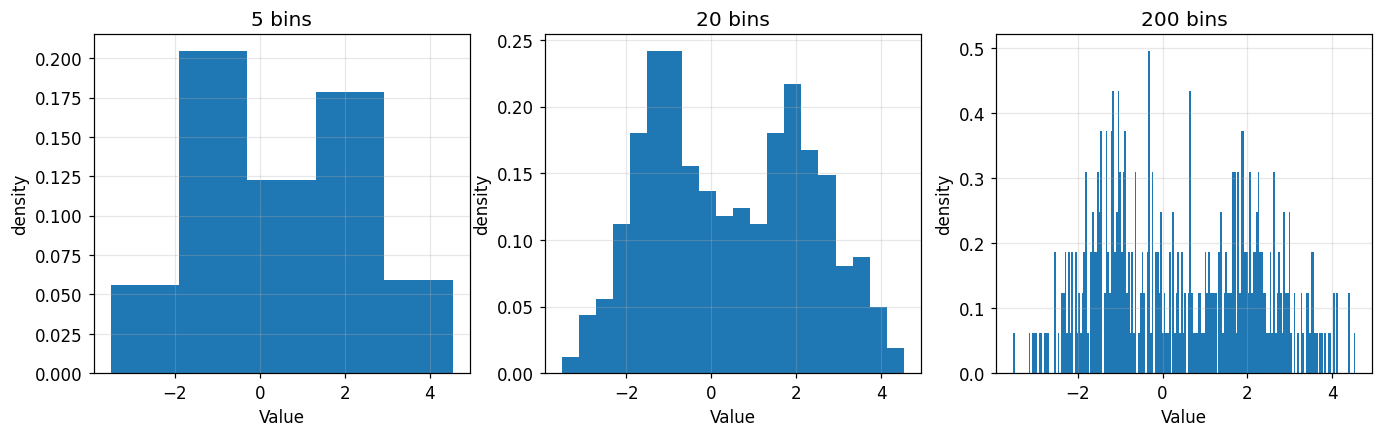

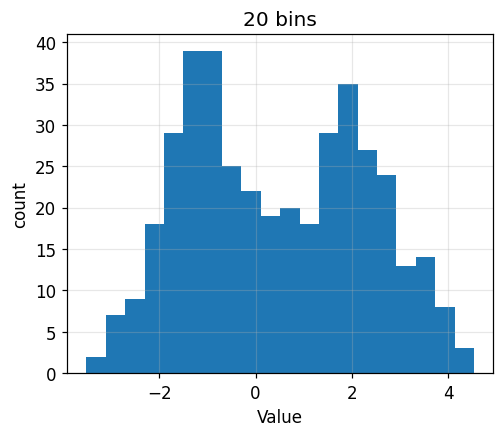

Task 10 passed.


In [ ]:
# A deliberately awkward sample: two overlapping normals, 400 points.
_mixture = np.concatenate([
    np.random.default_rng(7).normal(-1.0, 1.0, 200),
    np.random.default_rng(8).normal(2.0, 1.0, 200),
])

_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=True)

assert len(_axes) == 3, f"expected three panels, got {len(_axes)}"
for _ax in _axes:
    assert _ax.get_xlabel(), "a panel has no x label"
    assert _ax.get_ylabel() == "density", \
        f"with density=True the y axis is a density, not a {_ax.get_ylabel()!r}"
    assert _ax.get_title(), "a panel has no title"
    assert len(_ax.patches) > 0, "a panel has no bars"

_fig_count, _axes_count = histogram_grid(_mixture, [20], density=False)
assert _axes_count[0].get_ylabel() == "count"

plt.show()
print("Task 10 passed.")

### Question 5 — bin count and density

Look at the three panels you just produced from `_mixture`, which was built
from **two** normal components centred at -1 and +2.

**(a)** At which bin count is the two-component structure visible? At which
is it hidden? At 200 bins, are the peaks you see real?

**(b)** Re-run `histogram_grid(_mixture, [5, 20, 200], density=False)` and
compare the y axes with the `density=True` version. The shapes are
identical but the numbers are not. Explain what `density=True` divides by,
and why that makes two samples **of different sizes** comparable on one
axis where raw counts would not be.

**(c)** A colleague shows you a histogram with a clear double peak and
concludes the population has two subgroups. What is the first question you
ask them?

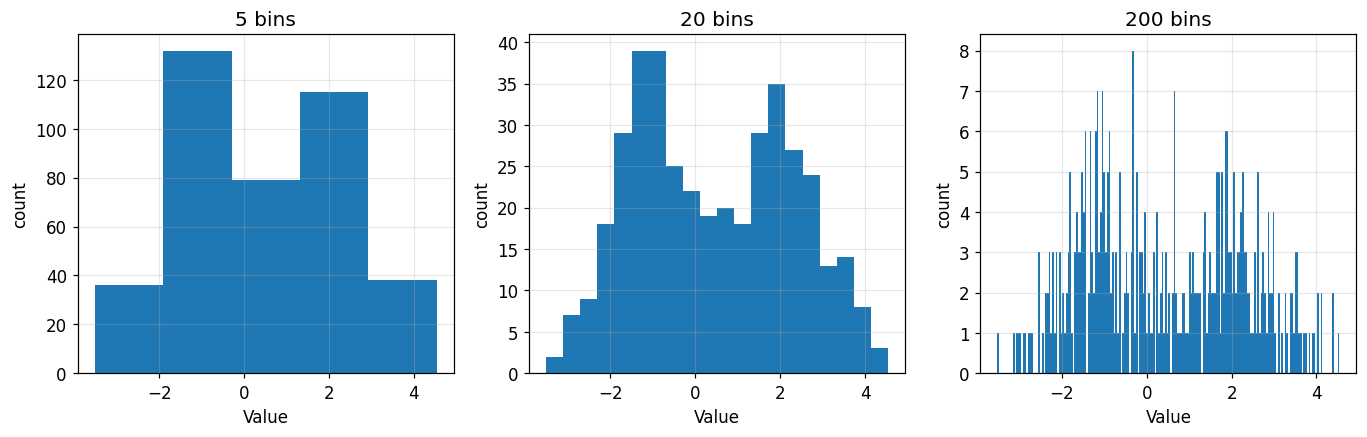

In [ ]:
fig, axes = histogram_grid(
    _mixture,
    [5, 20, 200],
    density=False
)

plt.show()

**Your answer:**

(a) The two-component structure is most clearly visible with about 20 bins. With only 5 bins, the histogram is too coarse and the two components are partly hidden because many observations are combined into wide bins. With 200 bins, the histogram becomes very noisy because there are only 400 observations, so many bins contain very few points. The many narrow peaks seen with 200 bins should therefore not be interpreted as real population peaks; most are sampling noise caused by using bins that are too narrow.

(b) With density=False, the y-axis shows the raw number of observations in each bin. With density=True, the histogram is normalized by the total sample size and the bin width so that the total area under the histogram is 1. In other words, the density for a bin is approximately count / (sample size × bin width). The shape of the histogram is therefore unchanged for the same bins, but the numerical scale of the y-axis changes. This normalization makes samples of different sizes comparable because doubling the number of observations would roughly double the raw counts, while the normalized density remains on the same probability-density scale.

(c) If a colleague showed me a histogram with a clear double peak, my first question would be: “How many bins did you use, and does the double peak remain when you change the bin count or bin width?” A histogram can create, hide, or exaggerate apparent peaks depending on the choice of bins, so I would check whether the pattern is robust before concluding that the population contains two subgroups.

## 12. Task 11 — Open-ended

No assert. This one is marked on the written analysis.

You are given a sample of 5000 measurements below, produced by a generator
whose parameters you are not told. Your task is to **characterise it and
say what you would do with the extreme values**, using only the tools from
Practice 1.

Work through at least the following, and write up what you find:

1. Describe the array: shape, dtype, how much memory it occupies.
2. Compute the mean, the median, the standard deviation, the minimum and
   the maximum. The mean and the median differ noticeably. What does that
   tell you before you have plotted anything?
3. Plot it as a histogram. Choose the bin count deliberately and justify
   your choice in one sentence.
4. Apply the k-sigma rule from Task 5 at k = 3. How many points are
   flagged? Compare that count with the roughly 0.27 % you would expect
   from a normal sample of this size.
5. Now the judgement. Recompute the mean and standard deviation **with the
   flagged points removed**. Report both versions. Then argue, in a
   paragraph, whether the flagged points should be removed — and be
   explicit about what you would need to know about *how the data was
   measured* before you could answer that with any confidence.

A good answer treats step 5 as a question about the measurement process,
not about the numbers. A weak answer deletes the outliers because a rule
said so.

In [ ]:
# The data. Do not modify this cell.
_hidden_rng = np.random.default_rng(31337)
mystery_sample = np.concatenate([
    _hidden_rng.normal(10.0, 2.0, 4_900),
    _hidden_rng.uniform(25.0, 60.0, 100),
])
_hidden_rng.shuffle(mystery_sample)

print("mystery_sample is ready:", mystery_sample.shape)

mystery_sample is ready: (5000,)


Shape: (5000,)
dtype: float64
ndim: 1
size: 5000
nbytes: 40000

Descriptive statistics:
Mean: 10.631054523018596
Median: 10.09249144940759
Standard deviation: 5.065035346894628
Minimum: 2.571604519822613
Maximum: 59.72793153394517


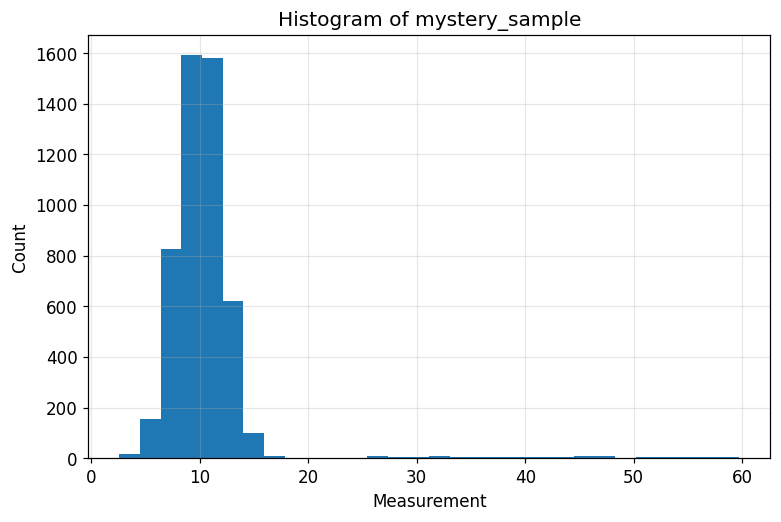


3-sigma analysis:
Number of flagged points: 94
Percentage flagged: 1.8800000000000001
Expected for normal data (~0.27%): 13.5

Before removing flagged points:
Mean: 10.631054523018596
Standard deviation: 5.065035346894628

After removing flagged points:
Mean: 10.020966697993872
Standard deviation: 2.0930020976036245
Remaining observations: 4906


In [ ]:
# 1. Describe the array
print("Shape:", mystery_sample.shape)
print("dtype:", mystery_sample.dtype)
print("ndim:", mystery_sample.ndim)
print("size:", mystery_sample.size)
print("nbytes:", mystery_sample.nbytes)

# 2. Descriptive statistics
mean = mystery_sample.mean()
median = np.median(mystery_sample)
std = mystery_sample.std()
minimum = mystery_sample.min()
maximum = mystery_sample.max()

print("\nDescriptive statistics:")
print("Mean:", mean)
print("Median:", median)
print("Standard deviation:", std)
print("Minimum:", minimum)
print("Maximum:", maximum)

# 3. Histogram
plt.figure(figsize=(8, 5))
plt.hist(mystery_sample, bins=30, density=False)
plt.xlabel("Measurement")
plt.ylabel("Count")
plt.title("Histogram of mystery_sample")
plt.show()

# 4. Apply the 3-sigma rule
mask, values = sigma_outliers(mystery_sample, k=3.0)

print("\n3-sigma analysis:")
print("Number of flagged points:", mask.sum())
print("Percentage flagged:", mask.mean() * 100)
print("Expected for normal data (~0.27%):", 0.0027 * mystery_sample.size)

# 5. Compare before and after removing flagged points
clean_sample = mystery_sample[~mask]

print("\nBefore removing flagged points:")
print("Mean:", mystery_sample.mean())
print("Standard deviation:", mystery_sample.std())

print("\nAfter removing flagged points:")
print("Mean:", clean_sample.mean())
print("Standard deviation:", clean_sample.std())
print("Remaining observations:", clean_sample.size)

**Your write-up:**

The mystery_sample contains 5,000 observations and has shape (5000,). It is a one-dimensional NumPy array with dtype float64 and occupies 40,000 bytes of memory.

The mean of the sample is approximately 10.6311, while the median is approximately 10.0925. The standard deviation is approximately 5.0650, with a minimum value of 2.5716 and a maximum value of 59.7279. The mean is noticeably larger than the median, which suggests that the distribution is positively skewed and contains unusually large values in the right tail.

I plotted the data using a histogram with 30 bins. I chose 30 bins because the sample contains 5,000 observations, so this provides enough resolution to reveal the overall distribution and the extreme right tail without making the histogram excessively noisy. The histogram shows that most observations are concentrated around 10, while a relatively small number of observations extend far to the right, reaching almost 60.

Using the k-sigma rule with k = 3, 94 observations were flagged as outliers. This is 1.88% of the 5,000 observations. If the sample were normally distributed, approximately 0.27% would be expected outside three standard deviations, corresponding to about 13.5 observations in a sample of this size. Therefore, the observed number of flagged values is much larger than the normal-distribution expectation.

Before removing the flagged observations, the sample mean is approximately 10.6311 and the standard deviation is approximately 5.0650. After removing them, 4,906 observations remain, the mean decreases to approximately 10.02097, and the standard deviation decreases substantially to approximately 2.0930. This shows that the extreme values have a considerable effect on both the mean and the standard deviation.

However, I would not automatically delete the 94 flagged observations simply because they are more than three standard deviations from the mean. Statistical extremeness alone does not demonstrate that a measurement is an error. Before deciding to remove them, I would need information about how the data were measured, including the valid measurement range, the measuring instrument, possible sensor or recording failures, calibration problems, and whether large values can occur legitimately in the phenomenon being studied. If there were independent evidence that these observations resulted from measurement or data-entry errors, removing them could be justified. If they are valid measurements, they should normally be retained because deleting them would remove real information and substantially change the estimated distribution.

## 13. Before you submit

- Runtime → **Restart and run all**. Every cell must execute in order with
  no error and every assert must pass.
- Every written question has an answer that refers to numbers you actually
  produced.
- Task 11 has a written conclusion, not only code.